In [58]:
# importações
from random import *
import numpy as np
import time

import copy
import operator

%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

def leitura(arquivo):
    arq = open(arquivo, "r") # r- read
    lixo = arq.readline()  # linha com texto Number of jobs
    linha = arq.readline() # linha com número de tarefas
    N = int(linha)         # linha com o número de tarefas
    r = np.zeros(N)
    p = np.zeros(N)  # p = [p0, p1,..., p(N-1)]
    w = np.zeros(N)
    d = np.zeros(N)
    lixo = arq.readline()  # linha com texto Job data (job number, release date, processing time, weight, due date)
    for i in range(N):  # repetir N vezes
        # i-ésima linha
        linha = arq.readline().split()  # posições: 0-indice 1-r, 2-p, 3-w, 4-d
        r[i] = int(linha[2])
        p[i] = int(linha[3])
        w[i] = int(linha[1])
        d[i] = int(linha[4])
    return N, w, r, p,d 

# def leitura(arquivo):
#     arq = open(arquivo, "r") # r- read
#     lixo = arq.readline()  # linha com texto Number of jobs
#     linha = arq.readline() # linha com número de tarefas
#     N = int(linha)         # linha com o número de tarefas
#     w = np.zeros(N)
#     r = np.zeros(N)
#     p = np.zeros(N)  # p = [p0, p1,..., p(N-1)]
#     d = np.zeros(N)
#     lixo = arq.readline()  # linha com texto Job data 
#     for i in range(N):  # repetir N vezes
#         # i-ésima linha
#         linha = arq.readline().split()  # posições: 0-indice, 1-w, 2-r, 3-p, 4-d
#         w[i] = int(linha[3])
#         r[i] = int(linha[1])
#         p[i] = int(linha[2])
#         d[i] = int(linha[4])
#     return N, r, p, w, d   

# inicializa população aleatoriamente
# cada individuo da populacao terá o seguinte formato:
# ([individuo], [lista com xi], funojb)
# para cada indivíduo i
# populacao[i][0]  para acessar o indivíduo (codificação real ou inteira)
# populacao[i][1]  para acessar a variável de decisão xi
# populacao[i][2]  para acessar a função-objetivo
def inicializaPopulacao(TP, N):
    populacao = []
    for i in range(TP):   # para cada individuo (lista) da populacao 
        lista = []
        todos = list(range(N))   # lista com todas as tarefas
        for j in range(N):                      # para cada posição do individuo
            aleatorio = choice(todos)           # escolher uma tarefa aleatoria 
            lista.append(aleatorio)             # adicionar à lista
            todos.remove(aleatorio)             # remover da lista auxiliar para não ocorrer repetição
        # alocar espaço para a variável de decisão
        x = [0]*N
        populacao.append([lista, x, 0])   # incluir o individuo completo na populacao
    return populacao

def decodificaX(populacao, TP, N, r, p, w, d):
    for i in range(TP):   # para cada individuo (lista) da populacao
        maquinaDisponivel = 0
        for j in range(N):                      # para cada posição do individuo
            tarefa = populacao[i][0][j]   # pega o índice da tarefa que deve ser processada na j-ésima posição
            if r[tarefa] > maquinaDisponivel:
                populacao[i][1][tarefa] = r[tarefa]   # x_tarefa = r_tarefa
            else:
                populacao[i][1][tarefa] = maquinaDisponivel
            maquinaDisponivel = populacao[i][1][tarefa] + p[tarefa]
            
def calculaObj(populacao, TP, N, r, p, w, d):
    Mgrande = 100*sum(d)
    for i in range(TP):   # para cada individuo (lista) da populacao
        fobj = 0
        penalizacao = 0
        for j in range(N):  
            xj = populacao[i][1][j]
            fobj = fobj + w[j]*(xj + p[j])
            if xj + p[j] - d[j] > 0:   # existe atraso
                penalizacao = penalizacao + xj + p[j] - d[j]
        populacao[i][2] = fobj + Mgrande*penalizacao     

        
#==================================================================
#==================================================================
#==================================================================

def selecao_torneio(pop, n):
    # escolhe um indivíduo qualquer e o considera vencedor
    vencedor = pop[randrange(len(pop))] 
    
    # escolhe n competidores e verifica quem é melhor:
    for i in range(n):
        competidor = pop[randrange(len(pop))]
        if competidor[2] < vencedor[2]:
            vencedor = competidor
        
    return vencedor

#==================================================================

def cruzamento(individuo1, individuo2):
  cromossomo1 = individuo1[0] # extrai genes do pai 1
  cromossomo2 = individuo2[0] # extrai genes o pai 2

  n_genes = len(cromossomo1) # encontra a quantidade de genes

  c_filho1 = [-1]*n_genes # cria filho1 com todos os genes igual a -1
  c_filho2 = [-1]*n_genes # cria filho2 com todos os genes igual a -1

  ponto = randrange(n_genes) # determina, aleatoriamente, um ponto de cruzamento

  #preenche filho1 com os primeiros genes do pai1 
  for i in range(ponto):
    c_filho1[i] = cromossomo1[i]

  # preenche o filho1 com os genes do pai2 que ainda não estão no filho1,
  # respeitando a ordem e a localização em que aparecem
  for i in range(ponto, n_genes):
    if cromossomo2[i] not in c_filho1:
      c_filho1[i] = cromossomo2[i]
  
  # completa filho1 com genes do pai2 nas posições faltantes, respeitando
  # a ordem em que cada gene aparecem no pai2
  k = 0
  for i in range(n_genes):
    if cromossomo2[i] not in c_filho1:
      while c_filho1[k] != -1:
        k += 1
      c_filho1[k] = cromossomo2[i]

  #preenche filho2 com os primeiros genes do pai2   
  for i in range(ponto):
    c_filho2[i] = cromossomo2[i]

  # preenche o filho2 com os genes do pai1 que ainda não estão no filho2,
  # respeitando a ordem e a localização em que aparecem
  for i in range(ponto, n_genes):
    if cromossomo1[i] not in c_filho2:
      c_filho2[i] = cromossomo1[i]

  # completa filho2 com genes do pai1 nas posições faltantes, respeitando
  # a ordem em que cada gene aparecem no pai1
  k = 0
  for i in range(n_genes):
    if cromossomo1[i] not in c_filho2:
      while c_filho2[k] != -1:
        k += 1
      c_filho2[k] = cromossomo1[i]
    
  # cria a estrutura do filho 1:
  filho1 = [c_filho1, [0]*n_genes, 0]
    
  # cria a estrutura do filho 2:
  filho2 = [c_filho2, [0]*n_genes, 0]
   
  # retorna os filhos criados:
  return  filho1, filho2

#==================================================================

def mutacao(individuo):
    cromossomo = individuo[0] # extrai genes
    n_genes = len(cromossomo) # verifica tamanho do cromossomo
  
    # seleciona dois pontos aleatórios
    ponto1 = randrange(1, n_genes) 
    ponto2 = randrange(1, n_genes)
    
    #realiza a troca das tarefas representadas por esses pontos
    cromossomo[ponto1],cromossomo[ponto2] = cromossomo[ponto2],cromossomo[ponto1]

#==================================================================

def encontra_melhor(lista):
    melhor = lista[0] # suponhamos que o primeiro elemento da lista é o melhor
    
    # percorremos a lista, comparando e atualizando o melhor
    for individuo in lista:
        if individuo[2] < melhor[2]:
            melhor = individuo
    
    return melhor
    
#==================================================================

def grafico_desempenho(individuos):
    x = list(range(len(individuos)))
    y = []
    for ind in individuos:
        y += [ind[2]]
        
    plt.title('Melhor por Geração (Codificação Inteira)')
    plt.xlabel('Gerações')
    plt.ylabel('Aptidão')
    plt.plot(x,y)

#==================================================================

def main():
    # constantes
    TP = 500     # tamanho da população
    G = 50    # número de gerações
    seed() #inicia a semente dos número pseudo randômicos
    
    # leitura
    #N, r, p, w, d = leitura("Instancia10.txt")
    N, w, r, p, d = leitura("Instancia10.txt")
    
    #N = 3
    #r = [2, 1, 4]
    #p = [1, 2, 3]
    #w = [1, 2, 3]
    #d = [5, 4, 8]
    
    inicio = time.time()  # começa a contar o tempo
    # Inicializa Populacao 
    populacao = inicializaPopulacao(TP, N)

    # Decodifica xi 
    decodificaX(populacao, TP, N, r, p, w, d)
    
    # Calcula a função objetivo penalizada
    calculaObj(populacao, TP, N, r, p, w, d)
    
    px = 0.9
    pm = 0.1
    
    elite = []

    print("Gerações: ")
    for g in range(G):
        nova = []
        print("... %d "%(g + 1), end="")
        while(len(nova) < TP):
            if random() < px:                
                ind1 = selecao_torneio(populacao, 3)
                ind2 = selecao_torneio(populacao, 3)
                
                filho1, filho2 = cruzamento(ind1, ind2)
                
                if random() < pm:
                    mutacao(filho1)
                    
                if random() < pm:
                    mutacao(filho2)
                    
                nova.append(filho1)
                nova.append(filho2)
        
        decodificaX(nova, TP, N, r, p, w, d)
        calculaObj(nova, TP, N, r, p, w, d)
        
        populacao = nova
        
        melhor_da_geracao = encontra_melhor(populacao)
        elite.append(melhor_da_geracao)
        
    # fim do GA
    fim = time.time()
    print("\n")
    
    print("Tempo de execução (s): ", fim - inicio)
    
    melhor_individuo = encontra_melhor(elite)
    print("\nMelhor valor encontrado: %d\n"%melhor_individuo[2])
    print(melhor_individuo)
    
    grafico_desempenho(elite)
    

Gerações: 
... 1 ... 2 ... 3 ... 4 ... 5 ... 6 ... 7 ... 8 ... 9 ... 10 ... 11 ... 12 ... 13 ... 14 ... 15 ... 16 ... 17 ... 18 ... 19 ... 20 ... 21 ... 22 ... 23 ... 24 ... 25 ... 26 ... 27 ... 28 ... 29 ... 30 ... 31 ... 32 ... 33 ... 34 ... 35 ... 36 ... 37 ... 38 ... 39 ... 40 ... 41 ... 42 ... 43 ... 44 ... 45 ... 46 ... 47 ... 48 ... 49 ... 50 

Tempo de execução (s):  0.8286001682281494

Melhor valor encontrado: 335

[[2, 8, 6, 4, 9, 1, 0, 5, 3, 7], [9.0, 7.0, 0, 12.0, 4.0, 11.0, 3.0, 13.0, 1.0, 5.0], 335.0]


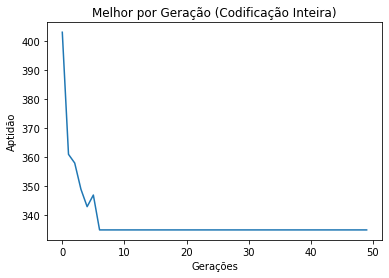

In [59]:
main()